# Part 4: Multivariate analysis

- **Owner:** Priya
- **Data:** `data/listings_clean.csv` from `01_cleaning.ipynb` (92,635 rows × 80 columns).
- **Main question:** which listing and host features predict a top rating (4.8 or higher), so hosts know what to improve first?
- **Where this part fits:** The univariate analysis examined individual variables, while the bivariate analysis examined relationships between pairs of variables. This multivariate stage combines multiple candidate features to determine which relationships remain useful when considered together.
- **Target variable:** `top_rated` (1 = overall rating of 4.8 or higher, 0 = below 4.8), defined in `01_cleaning.ipynb`. Every chart and table below is about this target.
- **Samples:** general views use all listings. Anything about `top_rated` uses the 70,708 rated listings only, so the results describe listings that already have reviews, not new listings.
- **Carried over from earlier decisions:**
  - Review sub-scores and `host_is_superhost` are never used as features (leakage).
  - `host_identity_verified` is not used: the univariate and bivariate parts found it near-universal (about 98% of listings), so it carries almost no information.
  - Host response rate, acceptance rate and response time are empty in this snapshot.
  - Price uses `price_capped_imp` with its missing flag; bedrooms, beds and bathrooms use the `_imp` columns with their missing flags (all from the cleaning part).
  - Classes are close to balanced, so no resampling.
- **Figure numbering:** continues from the bivariate part (Figures 13 to 21). This part has Figures 22 to 26, plus 23b (the same map story as animated bars).
- **Format:** Figures 22, 23, 23b and 26 are interactive Plotly charts (also saved as HTML in `figures/`). Figures 24 and 25 are static PNGs in the same style as the earlier parts.
- **Timing:** each computational step is timed, and Step 8 reports a CPU baseline that can be compared with a RAPIDS (GPU) run.

In [1]:
# GPU switch: must run BEFORE pandas is imported. Leave commented for the CPU baseline.
# %load_ext cudf.pandas

import os
import json
import time
import platform
import warnings
from contextlib import contextmanager

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from scipy.stats import norm
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

try:
    import plotly.graph_objects as go
except ImportError as e:
    raise ImportError("The interactive figures need Plotly: run  pip install -U plotly  and restart the kernel") from e

warnings.filterwarnings("ignore", category=FutureWarning)

MODE = "CPU"                                   # change to "GPU" on the RAPIDS run
DATA_PATH = "../data/listings_clean.csv"
FIG_DIR = "../figures"
DOC_DIR = "../docs"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(DOC_DIR, exist_ok=True)

# Same colours as the bivariate part; teal marks things a host can change, grey marks fixed context
BLUE, ORANGE, GREEN, PURPLE, CORAL, GREY = "#2E86AB", "#F18F01", "#2A9D8F", "#8E6CBE", "#E76F51", "#6C757D"
LEVER_COLOR, CONTEXT_COLOR = GREEN, "#B0B7BC"
RNG = 42

# Timing: every computational step is wrapped in timer(); the kind says whether a GPU (cuDF) run can speed it up
timing_rows = []

@contextmanager
def timer(label, kind="pandas"):
    t0 = time.perf_counter()
    yield
    timing_rows.append({"Step": label, "Kind": kind, "Seconds": time.perf_counter() - t0})


def clean_axes(ax):
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)


def save(fig, name):
    # Static charts: save as PNG like the earlier parts, then show
    fig.savefig(os.path.join(FIG_DIR, name + ".png"), dpi=300, bbox_inches="tight")
    plt.show()


def finish(fig, name, title, subtitle=None, height=520, bottom=None, top=95):
    # Interactive charts: shared look, saved as HTML in the figures folder, then shown
    text = f"<b>{title}</b>" + (f"<br><span style='font-size:13px;color:#555555'>{subtitle}</span>" if subtitle else "")
    has_frames = bool(getattr(fig, "frames", None))
    fig.update_layout(template="plotly_white", font=dict(family="Arial, sans-serif", size=13),
                      margin=dict(l=60, r=30, t=top, b=bottom if bottom else (120 if has_frames else 60)),
                      title=dict(text=text, x=0.01, xanchor="left"), height=height)
    try:
        fig.write_html(os.path.join(FIG_DIR, name + ".html"), include_plotlyjs="cdn")
    except Exception as err:
        print("could not save", name, "->", err)
    fig.show()


def wilson_interval(successes, n, confidence=0.95):
    # Wilson score interval for a proportion (same helper as the bivariate part)
    z = norm.ppf(1 - (1 - confidence) / 2)
    p = successes / n
    den = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / den
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / den
    return center - half, center + half


if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"{DATA_PATH} not found. Run 01_cleaning.ipynb first; it creates this file.")

with timer("Load cleaned CSV"):
    df = pd.read_csv(DATA_PATH, low_memory=False)

expected = (92635, 80)
if df.shape != expected:
    print(f"WARNING: expected {expected} from the latest cleaning output, got {df.shape}. Re-run 01_cleaning.ipynb.")
required = ["top_rated", "review_scores_rating", "price_capped", "price_capped_imp", "price_capped_missing", "room_type",
            "property_type", "accommodates", "bedrooms_imp", "beds_imp", "bathrooms_imp", "bedrooms_missing", "beds_missing",
            "bathrooms_missing", "size_extreme", "neighbourhood_cleansed", "latitude", "longitude",
            "calculated_host_listings_count", "hosts_time_as_host_years", "amenities", "minimum_nights_capped",
            "availability_365", "number_of_reviews"]
missing_cols = [c for c in required if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns from the latest cleaning output: {missing_cols}")

with timer("Create rated subset"):
    rated = df[df["top_rated"].notna()].copy()
    rated["top_rated"] = rated["top_rated"].astype(int)
BASE = rated["top_rated"].mean() * 100
VERIFIED = (rated["host_identity_verified"].astype(str).str.lower().isin(["t", "true", "1"])).mean() * 100
print(df.shape, "| rated:", len(rated), f"| overall top-rated rate: {BASE:.1f}% | host_identity_verified: {VERIFIED:.1f}% of rated listings")

(92635, 80) | rated: 70708 | overall top-rated rate: 56.1% | host_identity_verified: 98.4% of rated listings


## Step 1: Build the multivariate features

The earlier parts ended with a list of candidates and a list of cautions. This step turns them into columns ready for the combined analysis, without touching the cleaned file.

- **Grouped categories:** `property_type` has a long tail (top 5 kept), shared and hotel rooms are tiny (merged), and capacity is grouped as in the bivariate part.
- **Host type:** `calculated_host_listings_count` grouped into 1, 2-5 and 6+ listings. The bivariate part split only single vs multi-listing hosts; three groups let the map and curves show whether the gap grows with portfolio size.
- **Amenities:** parsed from JSON text into a count (same definition as the bivariate part) and a set of mid-frequency amenities. Near-universal amenities cannot separate listings, so they are left out.
- **Price:** the log of `price_capped_imp` (from cleaning) plus the `price_missing` flag, and a new **relative price**: a listing's observed price divided by the median of similar listings (same borough, room type and capacity group). This shows whether a listing is cheap or expensive for what it offers, which is something a host can change.
- **Size columns:** `bedrooms_imp`, `beds_imp`, `bathrooms_imp` with their missing flags and the `size_extreme` flag, as decided in cleaning.
- **Skewed counts:** log scale for reviews and minimum nights, as the univariate part recommended.
- **Not used:** `host_identity_verified` (near-universal, see the introduction).

In [2]:
CAP_BINS, CAP_LABELS = [0, 2, 4, 6, np.inf], ["1-2 guests", "3-4 guests", "5-6 guests", "7+ guests"]
HOST_ORDER = ["1 listing", "2-5 listings", "6+ listings"]


def add_features(d):
    d = d.copy()
    d["room_group"] = d["room_type"].where(d["room_type"].isin(["Entire home/apt", "Private room"]), "Shared or hotel room")
    top_props = d["property_type"].value_counts().head(5).index
    d["property_group"] = d["property_type"].where(d["property_type"].isin(top_props), "Other property type")
    d["capacity_group"] = pd.cut(d["accommodates"], bins=CAP_BINS, labels=CAP_LABELS).astype(object)
    d["host_type"] = pd.cut(d["calculated_host_listings_count"], bins=[0, 1, 5, np.inf], labels=HOST_ORDER).astype(object)
    # price: log of the cleaned price, missing flag from cleaning, and observed price relative to similar listings
    d["price_missing"] = d["price_capped_missing"].astype(int)
    d["log_price"] = np.log(d["price_capped_imp"])
    keys = ["neighbourhood_cleansed", "room_group", "capacity_group"]
    peer = d.groupby(keys)["price_capped"].transform("median")
    peer_n = d.groupby(keys)["price_capped"].transform("count")
    d["price_vs_peers"] = d["price_capped"] / peer.where(peer_n >= 10)   # observed prices only; needs at least 10 priced peers
    # skewed counts
    d["log_reviews"] = np.log1p(d["number_of_reviews"])
    d["log_min_nights"] = np.log1p(d["minimum_nights_capped"])
    d["log_host_listings"] = np.log1p(d["calculated_host_listings_count"].astype(float))
    return d


with timer("Feature engineering (grouping, relative price, logs)"):
    rated = add_features(rated)

with timer("Amenity JSON parsing", kind="cpu-only"):
    am = rated["amenities"].apply(lambda s: json.loads(s) if isinstance(s, str) else [])
    rated["amenity_count"] = am.str.len()                      # same definition as the bivariate part
    amen_sets = am.apply(lambda L: {x.strip().lower() for x in L})

# mid-frequency amenities: offered by 10-80% of rated listings (basics and brand names cannot separate listings)
with timer("Amenity indicator matrix", kind="cpu-only"):
    am_share = amen_sets.explode().value_counts() / len(rated)
    am_share = am_share[(am_share >= 0.10) & (am_share <= 0.80)]
    AMEN = [a for a in am_share.sort_values(ascending=False).head(60).index if len(a) <= 40][:40]
    amen_matrix = pd.DataFrame({a: amen_sets.apply(lambda s, a=a: a in s) for a in AMEN}, index=rated.index)

print("rated listings:", len(rated), "| with a relative price:", f"{int(rated['price_vs_peers'].notna().sum()):,}",
      "| mid-frequency amenities kept:", len(AMEN))
rated[["room_group", "capacity_group", "host_type", "price_vs_peers", "amenity_count"]].head()

rated listings: 70708 | with a relative price: 48,378 | mid-frequency amenities kept: 40


,room_group,capacity_group,host_type,price_vs_peers,amenity_count
0,Entire home/apt,5-6 guests,1 listing,0.808621,43
1,Private room,1-2 guests,2-5 listings,1.351064,44
2,Entire home/apt,1-2 guests,1 listing,0.694444,25
3,Entire home/apt,5-6 guests,2-5 listings,1.292850,40
4,Private room,1-2 guests,2-5 listings,0.864557,24


## Figure 22: Which features move together? (interactive correlation heatmap)

Before combining the features, check which candidate features carry the same information. The heatmap shows **Spearman rank correlations** between the numeric candidates and the target `top_rated` (rank correlation suits the skewed counts and the 0/1 target). Blue means the two move together, orange means one goes up when the other goes down. **Hover** over a cell to see the pair and its exact value.

How to read it:
- The bottom row and right column show how each feature relates to `top_rated` on its own (the same single-variable view as the bivariate part).
- Strong cells between two features (for example size and price) mean they overlap, so their importance is shared between them. This is why importance is reported for **groups** of features in Figure 25.

In [3]:
CORR_COLS = {"top_rated": "Top rated", "accommodates": "Guests", "bedrooms_imp": "Bedrooms", "beds_imp": "Beds",
             "bathrooms_imp": "Bathrooms", "log_price": "Log price", "price_vs_peers": "Price vs similar",
             "amenity_count": "Amenity count", "log_min_nights": "Log min nights", "availability_365": "Days available",
             "log_reviews": "Log reviews", "hosts_time_as_host_years": "Host tenure", "log_host_listings": "Log host listings"}

with timer("Spearman correlation matrix"):
    corr = rated[list(CORR_COLS)].corr(method="spearman")
labels = list(CORR_COLS.values())
z = corr.to_numpy().round(2)

fig = go.Figure(data=[go.Heatmap(
    z=z, x=labels, y=labels, zmin=-1, zmax=1, xgap=1, ygap=1,
    colorscale=[[0, ORANGE], [0.5, "#F7F7F7"], [1, BLUE]],
    text=z, texttemplate="%{text:.2f}", textfont=dict(size=10),
    hovertemplate="<b>%{y}</b> vs <b>%{x}</b><br>Spearman ρ = %{z:.2f}<extra></extra>",
    colorbar=dict(title=dict(text="Spearman ρ")))])
fig.update_layout(yaxis=dict(autorange="reversed", automargin=True), xaxis=dict(tickangle=-40, automargin=True))
finish(fig, "fig22_correlation_heatmap", "Which features move together?",
       "Spearman correlation between candidate features and the target. Hover for exact values.", height=640, bottom=140)

tr = corr["top_rated"].drop("top_rated")
tr = tr.reindex(tr.abs().sort_values(ascending=False).index)
pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().rename("rho").reset_index())
pairs.columns = ["a", "b", "rho"]
pairs = pairs[(pairs["a"] != "top_rated") & (pairs["b"] != "top_rated")]
strong = pairs[pairs["rho"].abs() >= 0.6].sort_values("rho", key=abs, ascending=False)
display(Markdown(
    "**Insight:** on their own, the features most related to `top_rated` are "
    + ", ".join(f"**{CORR_COLS[k]}** (ρ = {v:+.2f})" for k, v in tr.head(4).items())
    + ". No single feature has |ρ| above "
    + f"{tr.abs().max():.2f} with the target, so a rating cannot be predicted from one variable. "
    + (f"{len(strong)} feature pairs overlap strongly (|ρ| ≥ 0.6), mainly the size measures and price: "
       + "; ".join(f"{CORR_COLS[r.a]} and {CORR_COLS[r.b]} ({r.rho:+.2f})" for r in strong.head(5).itertuples())
       + ". Overlapping features share credit, so the next steps judge importance by group."
       if len(strong) else "No pair of features overlaps strongly (|ρ| ≥ 0.6).")))

Figure()

**Insight:** on their own, the features most related to `top_rated` are **Log host listings** (ρ = -0.28), **Price vs similar** (ρ = +0.18), **Log min nights** (ρ = +0.14), **Days available** (ρ = -0.12). No single feature has |ρ| above 0.28 with the target, so a rating cannot be predicted from one variable. 5 feature pairs overlap strongly (|ρ| ≥ 0.6), mainly the size measures and price: Guests and Beds (+0.78); Guests and Bedrooms (+0.74); Guests and Log price (+0.66); Bedrooms and Beds (+0.66); Beds and Log price (+0.66). Overlapping features share credit, so the next steps judge importance by group.

## Figure 23: Where are top-rated listings, and does it depend on who the host is? (interactive map)

The univariate part left point maps for later because borough already carries the location. With host type in play, a map shows what single-variable charts could not: whether high and low top-rated areas cluster together, and whether the host-type gap is the same everywhere.

Each bubble is a borough. Its **size** is the number of rated listings and its **colour** is the top-rated rate (blue above the overall rate, orange below). **Hover** for the rate, its 95% Wilson interval, the number of rated listings and the median price. **Press Play** to step from all hosts to single-listing hosts, hosts with 2-5 listings, and hosts with 6 or more. Bubble size and colour use the same scale in every step, so the frames can be compared directly. Boroughs with fewer than 30 rated listings in a step are not shown.

*If Play does nothing in your editor, drag the slider, or open `figures/fig23_borough_map_by_host_type.html` in a browser. The map background needs an internet connection.*

In [4]:
MIN_N = 30
CENTER = dict(lat=float(df["latitude"].median()), lon=float(df["longitude"].median()))
RANGE = [max(0, BASE - 20), min(100, BASE + 20)]
FRAME_ORDER = ["All hosts"] + HOST_ORDER                 # fixed order: Play starts at All hosts

with timer("Borough × host-type aggregation"):
    cent = df.groupby("neighbourhood_cleansed")[["latitude", "longitude"]].mean()
    parts = []
    for label, d in [("All hosts", rated)] + [(h, rated[rated["host_type"] == h]) for h in HOST_ORDER]:
        s = d.groupby("neighbourhood_cleansed").agg(n=("top_rated", "size"), wins=("top_rated", "sum"),
                                                    rate=("top_rated", "mean"), median_price=("price_capped", "median")).reset_index()
        s["ci_low"], s["ci_high"] = wilson_interval(s["wins"].astype(float), s["n"].astype(float), 0.95)
        s["rate"], s["ci_low"], s["ci_high"] = s["rate"] * 100, s["ci_low"] * 100, s["ci_high"] * 100
        s["Host type"] = label
        parts.append(s[s["n"] >= MIN_N])
    bm = pd.concat(parts).merge(cent.reset_index(), on="neighbourhood_cleansed")
    bm["median_price"] = bm["median_price"].round(0)

# Plotly 5.24+ has Scattermap (MapLibre); older versions have Scattermapbox. Both work without a token.
USE_NEW_MAP = hasattr(go, "Scattermap")
MapTrace = go.Scattermap if USE_NEW_MAP else go.Scattermapbox
SIZEREF = 2 * bm["n"].max() / (44 ** 2)                  # one bubble scale for every frame (largest bubble = 44 px)


def map_trace(d):
    return MapTrace(
        lat=d["latitude"], lon=d["longitude"], mode="markers", text=d["neighbourhood_cleansed"],
        marker=dict(size=d["n"], sizemode="area", sizeref=SIZEREF, sizemin=5, opacity=0.85,
                    color=d["rate"], colorscale=[[0, ORANGE], [0.5, "#F2F2F2"], [1, BLUE]], cmin=RANGE[0], cmax=RANGE[1],
                    showscale=True, colorbar=dict(title=dict(text="Top-rated %"))),
        customdata=np.stack([d["n"], d["rate"], d["median_price"], d["ci_low"], d["ci_high"]], axis=-1),
        hovertemplate=("<b>%{text}</b><br>Rated listings: %{customdata[0]:,}<br>Top-rated: %{customdata[1]:.1f}% "
                       "(95% interval %{customdata[3]:.1f}% to %{customdata[4]:.1f}%)"
                       "<br>Median price: £%{customdata[2]:,.0f}<extra></extra>"),
        showlegend=False)


def add_play(fig, ms=1500, y=-0.04):
    # Play / Pause buttons plus a slider for a figure whose frames were built by hand.
    # redraw=True is needed for map traces; transition=0 stops bubbles from sliding between frames.
    names = [f["name"] for f in fig.frames]
    fig.update_layout(
        updatemenus=[dict(type="buttons", direction="left", x=0.0, y=y, xanchor="left", yanchor="top", showactive=False,
                          buttons=[dict(label="Play", method="animate",
                                        args=[None, dict(frame=dict(duration=ms, redraw=True), fromcurrent=True,
                                                         transition=dict(duration=0), mode="immediate")]),
                                   dict(label="Pause", method="animate",
                                        args=[[None], dict(frame=dict(duration=0, redraw=False), mode="immediate",
                                                           transition=dict(duration=0))])])],
        sliders=[dict(active=0, x=0.16, len=0.84, y=y, yanchor="top", currentvalue=dict(prefix="Showing: "),
                      steps=[dict(label=n, method="animate",
                                  args=[[n], dict(mode="immediate", frame=dict(duration=0, redraw=True),
                                                  transition=dict(duration=0))]) for n in names])])


frames = [go.Frame(name=lab, data=[map_trace(bm[bm["Host type"] == lab])]) for lab in FRAME_ORDER]
fig = go.Figure(data=[map_trace(bm[bm["Host type"] == FRAME_ORDER[0]])], frames=frames)
map_layout = dict(style="open-street-map", center=CENTER, zoom=8.6)
fig.update_layout(**({"map": map_layout} if USE_NEW_MAP else {"mapbox": map_layout}))
add_play(fig, ms=1500, y=-0.04)
finish(fig, "fig23_borough_map_by_host_type", "Top-rated rate across London boroughs",
       "Bubble size = rated listings, colour = top-rated rate. Press Play or use the slider to change host type.",
       height=700, bottom=150)

allh = bm[bm["Host type"] == "All hosts"]
top3 = allh.nlargest(3, "rate")["neighbourhood_cleansed"].tolist()
bot3 = allh.nsmallest(3, "rate")["neighbourhood_cleansed"].tolist()
mv = bm.pivot_table(index="neighbourhood_cleansed", columns="Host type", values="rate")
shift = (mv["6+ listings"] - mv["1 listing"]).dropna() if {"6+ listings", "1 listing"} <= set(mv.columns) else pd.Series(dtype=float)
nat = bm[bm["Host type"] != "All hosts"].groupby("Host type").apply(lambda g: (g["rate"] * g["n"]).sum() / g["n"].sum())
display(Markdown(
    f"**Insight:** the highest top-rated rates are in {', '.join(top3)} and the lowest in {', '.join(bot3)}. "
    + (f"Across London, listings of single-listing hosts are top-rated {nat.get('1 listing', np.nan):.0f}% of the time, "
       f"against {nat.get('2-5 listings', np.nan):.0f}% for hosts with 2-5 listings and {nat.get('6+ listings', np.nan):.0f}% for hosts with 6 or more. "
       f"Of the {len(shift)} boroughs with enough listings of both host types, hosts with 6+ listings do better than single-listing hosts in "
       f"{int((shift > 0).sum())} and worse in {int((shift < 0).sum())}, so the host-type gap is "
       + ("in the same direction in every borough." if (shift > 0).sum() == 0 or (shift < 0).sum() == 0 else
          ("in the same direction in almost every borough (a few exceptions)." if min((shift > 0).sum(), (shift < 0).sum()) <= 0.1 * len(shift)
           else "not the same everywhere.")) if len(shift) else "")))

Figure()

**Insight:** the highest top-rated rates are in Richmond upon Thames, Merton, Wandsworth and the lowest in City of London, Westminster, Camden. Across London, listings of single-listing hosts are top-rated 69% of the time, against 59% for hosts with 2-5 listings and 37% for hosts with 6 or more. Of the 33 boroughs with enough listings of both host types, hosts with 6+ listings do better than single-listing hosts in 1 and worse in 32, so the host-type gap is in the same direction in almost every borough (a few exceptions).

## Figure 23b: The same story without a map (animated ranked bars)

If the map does not load (it needs an internet connection for the background), or if you want to read exact values, this version shows the same numbers as horizontal bars. **Press Play** to step through all hosts, single-listing hosts, hosts with 2-5 listings and hosts with 6 or more; you can also drag the slider. The boroughs stay in the same order (ranked by the all-hosts rate), so you can see each borough move relative to the others. **Blue** bars are above the London average, **orange** bars below; the dashed line is the average. The thin line on each bar is the 95% Wilson interval, and **hover** shows the number of rated listings. Boroughs with fewer than 30 rated listings in a step are left blank.

In [5]:
order = allh.sort_values("rate")["neighbourhood_cleansed"].tolist()          # lowest first, so the highest bar is drawn at the top


def bar_trace(lab):
    d = bm[bm["Host type"] == lab].set_index("neighbourhood_cleansed").reindex(order)
    x = d["rate"].to_numpy()
    colors = np.where(x >= BASE, BLUE, ORANGE)
    return go.Bar(
        x=x, y=order, orientation="h", marker=dict(color=[str(c) for c in colors]),
        error_x=dict(type="data", symmetric=False, array=(d["ci_high"] - d["rate"]).to_numpy(), arrayminus=(d["rate"] - d["ci_low"]).to_numpy(),
                     color="#333333", thickness=1.2, width=3),
        customdata=np.stack([d["n"].to_numpy(), d["ci_low"].to_numpy(), d["ci_high"].to_numpy()], axis=-1),
        hovertemplate="<b>%{y}</b><br>Top-rated: %{x:.1f}% (95% interval %{customdata[1]:.1f}% to %{customdata[2]:.1f}%)"
                      "<br>Rated listings: %{customdata[0]:,.0f}<extra></extra>",
        showlegend=False)


frames_b = [go.Frame(name=lab, data=[bar_trace(lab)]) for lab in FRAME_ORDER]
fig = go.Figure(data=[bar_trace(FRAME_ORDER[0])], frames=frames_b)
fig.update_layout(
    xaxis=dict(title=dict(text="Top-rated listings (%)"), range=[0, 100]),
    yaxis=dict(categoryorder="array", categoryarray=order, automargin=True, tickfont=dict(size=11)),
    shapes=[dict(type="line", xref="x", yref="paper", x0=BASE, x1=BASE, y0=0, y1=1, line=dict(color="#444444", width=1.5, dash="dash"))],
    annotations=[dict(x=BASE, y=1.0, xref="x", yref="paper", text=f"London average {BASE:.1f}%", showarrow=False, yanchor="bottom", xanchor="left", font=dict(size=11, color="#444444"))],
    bargap=0.25)
add_play(fig, ms=1500, y=-0.07)
finish(fig, "fig23b_borough_bars_by_host_type", "Top-rated rate by borough, by host type",
       "Blue = above the London average, orange = below. Press Play or use the slider to change host type.", height=900, bottom=160, top=110)
single = mv["1 listing"] if "1 listing" in mv.columns else None
display(Markdown(
    "**Insight:** switching from single-listing hosts to hosts with 6 or more listings pulls almost every borough below the London average: "
    f"{int((mv['6+ listings'] < BASE).sum())} of {int(mv['6+ listings'].notna().sum())} boroughs with enough listings sit below it for 6+ hosts, "
    f"against {int((mv['1 listing'] < BASE).sum())} of {int(mv['1 listing'].notna().sum())} for single-listing hosts."))

Figure()

**Insight:** switching from single-listing hosts to hosts with 6 or more listings pulls almost every borough below the London average: 32 of 33 boroughs with enough listings sit below it for 6+ hosts, against 1 of 33 for single-listing hosts.

## Step 2: Do all the features together predict a top rating (4.8 or higher)?

The map shows one slice at a time. Here every allowed feature is used at the same time, so effects that bend or depend on each other can show up (the bivariate part suggested this for capacity, host tenure and minimum nights). Decisions from earlier parts that shape it:

- **No leakage:** review sub-scores and `host_is_superhost` are excluded. Latitude and longitude are excluded because borough already covers location.
- **Not prioritised:** `host_identity_verified` is left out (near-universal), so the host profile group holds only tenure and portfolio size.
- **Missing values:** price, bedrooms, beds and bathrooms use the median-by-room-type columns from cleaning with their missing flags. Relative price is missing for listings with no price, and the method handles that natively.

Features are put into groups, and the groups are added one at a time so the contribution of each is visible. Groups made of things a host can change are marked as **host choices**.

How well the features predict a top rating is reported three ways: a score on listings kept aside (AUC), a **95% interval** around that score (listings resampled 1,000 times), and a **5-fold cross-validation** score. A **simple straight-line rule** on the same features is the comparison: if the full analysis barely beats it, the extra complexity would not be worth it.

In [6]:
cat_cols = ["room_group", "property_group", "neighbourhood_cleansed"]
X = pd.DataFrame(index=rated.index)
for c in cat_cols:
    cd, _ = pd.factorize(rated[c])
    X[c] = np.where(cd < 0, np.nan, cd).astype(float)
num_feats = ["accommodates", "bedrooms_imp", "beds_imp", "bathrooms_imp", "bedrooms_missing", "beds_missing", "bathrooms_missing",
             "size_extreme", "hosts_time_as_host_years", "log_host_listings", "log_price", "price_missing", "price_vs_peers",
             "log_min_nights", "availability_365", "amenity_count", "log_reviews"]
for c in num_feats:
    X[c] = rated[c].astype(float)
HAS_INSTANT = "instant_bookable" in rated.columns
if HAS_INSTANT:
    X["instant_bookable"] = rated["instant_bookable"].map({"t": 1.0, "f": 0.0})
amen_cols = []
for a in AMEN:
    X["amenity: " + a] = amen_matrix[a].astype(float)
    amen_cols.append("amenity: " + a)

GROUPS = {
    "Fixed context": ["room_group", "property_group", "accommodates", "bedrooms_imp", "beds_imp", "bathrooms_imp",
                      "bedrooms_missing", "beds_missing", "bathrooms_missing", "size_extreme", "neighbourhood_cleansed"],
    "Host profile": ["hosts_time_as_host_years", "log_host_listings"],
    "Pricing": ["log_price", "price_missing", "price_vs_peers"],
    "Booking rules": ["log_min_nights", "availability_365"] + (["instant_bookable"] if HAS_INSTANT else []),
    "Amenities": ["amenity_count"] + amen_cols,
    "Review activity": ["log_reviews"],
}
LEVERS = {"Pricing", "Booking rules", "Amenities"}
GROUP_COLORS = {g: (LEVER_COLOR if g in LEVERS else CONTEXT_COLOR) for g in GROUPS}
assert "host_identity_verified" not in X.columns, "host_identity_verified must not be a feature (near-universal)"
assert not any(c.startswith("review_scores") or c == "host_is_superhost" for c in X.columns), "leakage columns in X"

y_all = rated["top_rated"].to_numpy()
with timer("Train/test split"):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y_all, test_size=0.25, stratify=y_all, random_state=RNG)


def fit(cols, Xtr=None, ytr=None):
    Xtr = X_tr if Xtr is None else Xtr
    ytr = y_tr if ytr is None else ytr
    mask = [c in cat_cols for c in cols]
    m = HistGradientBoostingClassifier(max_iter=250, learning_rate=0.07, max_leaf_nodes=31, min_samples_leaf=40,
                                       l2_regularization=1.0, early_stopping=True, validation_fraction=0.12, n_iter_no_change=15,
                                       categorical_features=mask if any(mask) else None, random_state=RNG)
    return m.fit(Xtr[cols], ytr)


with timer("Add feature groups one at a time (6 fits)", kind="cpu-only"):
    steps, cols_so_far, models = [], [], {}
    for g, cols in GROUPS.items():
        cols_so_far = cols_so_far + cols
        m = fit(cols_so_far)
        steps.append(dict(group=g, auc=roc_auc_score(y_te, m.predict_proba(X_te[cols_so_far])[:, 1])))
        models[g] = (m, list(cols_so_far))
model, MODEL_COLS = models["Review activity"]
names = [s["group"] for s in steps]
aucs = [s["auc"] for s in steps]
gains = np.diff([0.5] + aucs)
print("train:", len(X_tr), "| test:", len(X_te), "| features used:", len(MODEL_COLS))
print("AUC with all features:", round(aucs[-1], 3), "(0.5 = coin toss, 1.0 = perfect)")
pd.DataFrame({"group added": names, "test AUC": np.round(aucs, 3), "AUC gained": np.round(gains, 3)})

train: 53031 | test: 17677 | features used: 60
AUC with all features: 0.77 (0.5 = coin toss, 1.0 = perfect)


,group added,test AUC,AUC gained
0,Fixed context,0.637,0.137
1,Host profile,0.705,0.068
2,Pricing,0.715,0.010
3,Booking rules,0.729,0.014
4,Amenities,0.749,0.020
5,Review activity,0.770,0.021


## Figure 24: Can listing and host features predict a top rating (4.8 or higher), and do the things a host controls help?

**Why this figure is here.** Our question is *which listing and host features predict a top rating (4.8 or higher), so hosts know what to improve first*. Before telling hosts what to improve, we check two things: (1) do these features predict a top rating at all, and (2) do the features a host **can change** carry real information, or is a top rating mostly decided by things a host cannot change?

**How to read the score (AUC), in plain words.** Pick one top-rated listing and one other listing at random. The score is how often the features rank the top-rated one higher. **50% (0.50) is a coin toss; 100% (1.00) is perfect.** For example, 0.77 means the features get that ranking right about 77 times in 100.

**How to read the chart.** Each row uses a different set of features. The dot is its score on listings it has never seen; the short line around it is a **95% interval** (the test listings were resampled 1,000 times; a short line means the score is stable). The white diamond is a second check, **5-fold cross-validation**, which repeats the test on five different splits of the data.

| Row | Features it uses | What it tells hosts |
|---|---|---|
| **All features together** | Everything allowed | The best prediction we can make from listing data |
| **Fixed facts only** | Things a host cannot change (room type, size, borough, host profile, number of reviews) | How much of a top rating is already set before the host does anything |
| **Host choices only** | Things a host can change (price, minimum nights, availability, amenities) | Whether a host's own choices carry real signal |
| **Simple straight-line rule** | Everything, but each feature can only push the chance up or down in a straight line | A simple comparison: the full analysis should clearly beat it, or the extra complexity is not worth it |

**What to look for:** the host-choices row is well above 0.50, so what hosts control does predict a top rating; and the all-features row is higher than either half, so fixed facts and host choices add different information.

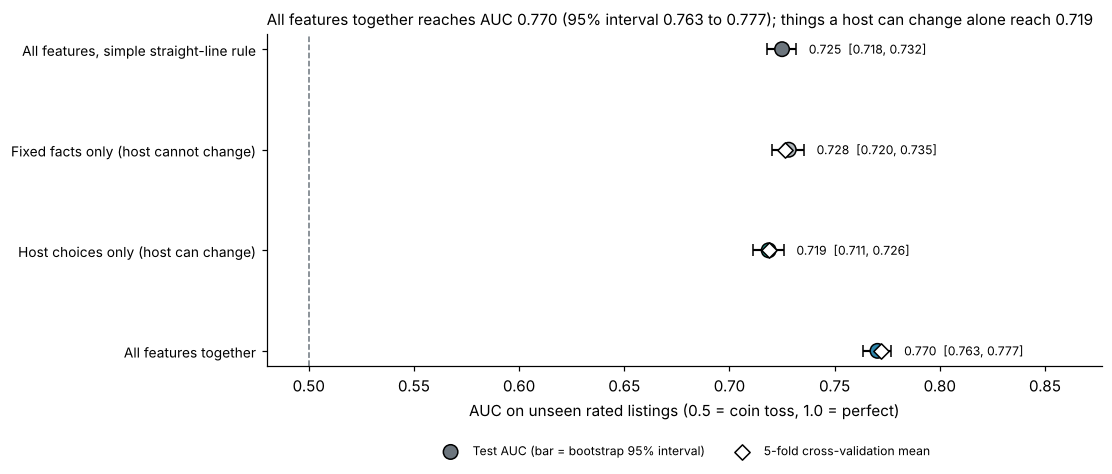

**Insight:** all features together scores **0.770** on unseen listings (bootstrap 95% interval 0.763 to 0.777; 5-fold cross-validation 0.772 ± 0.001). It beats the simple straight-line rule (0.725) by 0.045 AUC (resampled gap 0.041 to 0.050), which supports letting effects bend and interact. Everything a host cannot change (fixed context, host profile, review activity) scores 0.728; the things a host can change (pricing, booking rules, amenities) score 0.719 on their own, and using both reaches 0.770. So a host's own choices carry real but limited signal: a rating of 4.8 is far from fully predictable from listing data. This ranks listings in this snapshot; it does not forecast a rating.

,model,auc,low,high,cv_mean,cv_sd
0,"All features, simple straight-line rule",0.725,0.718,0.732,NaN,NaN
1,Fixed facts only (host cannot change),0.728,0.720,0.735,0.726,0.003
2,Host choices only (host can change),0.719,0.711,0.726,0.719,0.004
3,All features together,0.770,0.763,0.777,0.772,0.001


In [7]:
B = 1000
IDX = np.random.default_rng(RNG).integers(0, len(y_te), size=(B, len(y_te)), dtype=np.int32)   # one set of resamples, shared by every row


def boot_ci(y_true, p):
    # Percentile bootstrap of the test AUC. All models use the same resamples, so differences between models are paired.
    vals = np.array([roc_auc_score(y_true[i], p[i]) for i in IDX])
    return np.percentile(vals, [2.5, 97.5]), vals


ctx_cols = [c for g, cs in GROUPS.items() if g not in LEVERS for c in cs]
lev_cols = [c for g, cs in GROUPS.items() if g in LEVERS for c in cs]

with timer("Fixed-facts-only and host-choices-only (2 fits)", kind="cpu-only"):
    m_ctx, m_lev = fit(ctx_cols), fit(lev_cols)

# Straight-line comparison: one-hot categories, median fill, standardised numbers
with timer("Straight-line comparison", kind="cpu-only"):
    Xl = pd.concat([X.drop(columns=cat_cols), pd.get_dummies(rated[cat_cols], dtype=float)], axis=1)
    lin = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), LogisticRegression(max_iter=2000, C=0.5))
    lin.fit(Xl.loc[X_tr.index], y_tr)
    p_lin = lin.predict_proba(Xl.loc[X_te.index])[:, 1]

preds = {"All features, simple straight-line rule": p_lin,
         "Fixed facts only (host cannot change)": m_ctx.predict_proba(X_te[ctx_cols])[:, 1],
         "Host choices only (host can change)": m_lev.predict_proba(X_te[lev_cols])[:, 1],
         "All features together": model.predict_proba(X_te[MODEL_COLS])[:, 1]}

with timer("95% intervals for the score (1,000 resamples)", kind="cpu-only"):
    res, boot_vals = [], {}
    for name, p in preds.items():
        ci, vals = boot_ci(y_te, p)
        boot_vals[name] = vals
        res.append(dict(model=name, auc=roc_auc_score(y_te, p), low=ci[0], high=ci[1]))
res = pd.DataFrame(res)

# 5-fold cross-validation on the full training+test data (a second check on the same models)
with timer("5-fold cross-validation (3 sets of features: 15 fits)", kind="cpu-only"):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
    cv = {"Fixed facts only (host cannot change)": [], "Host choices only (host can change)": [], "All features together": []}
    cols_for = {"Fixed facts only (host cannot change)": ctx_cols, "Host choices only (host can change)": lev_cols, "All features together": MODEL_COLS}
    for tr_i, te_i in skf.split(X, y_all):
        for name, cols in cols_for.items():
            mm = fit(cols, X.iloc[tr_i], y_all[tr_i])
            cv[name].append(roc_auc_score(y_all[te_i], mm.predict_proba(X.iloc[te_i][cols])[:, 1]))
cvs = pd.DataFrame({k: [np.mean(v), np.std(v)] for k, v in cv.items()}, index=["cv_mean", "cv_sd"]).T
res = res.merge(cvs, left_on="model", right_index=True, how="left")

fig, ax = plt.subplots(figsize=(10, 4.2), layout="constrained")
yy = np.arange(len(res))[::-1]
cols_plot = [GREY, CONTEXT_COLOR, LEVER_COLOR, BLUE]
ax.errorbar(res["auc"], yy, xerr=[res["auc"] - res["low"], res["high"] - res["auc"]], fmt="none", ecolor="black", elinewidth=1.4, capsize=4, zorder=3)
ax.scatter(res["auc"], yy, s=90, color=cols_plot, edgecolor="black", zorder=4, label="Test AUC (bar = bootstrap 95% interval)")
cvm = res.dropna(subset=["cv_mean"])
ax.scatter(cvm["cv_mean"], yy[cvm.index], marker="D", s=50, color="white", edgecolor="black", zorder=5, label="5-fold cross-validation mean")
for yi, r in zip(yy, res.itertuples()):
    ax.text(max(r.high, r.cv_mean if r.cv_mean == r.cv_mean else 0) + 0.006, yi, f"{r.auc:.3f}  [{r.low:.3f}, {r.high:.3f}]", va="center", fontsize=8)
ax.set_yticks(yy)
ax.set_yticklabels(res["model"], fontsize=9)
ax.axvline(0.5, color=GREY, ls="--", lw=1)
ax.set_xlim(0.48, res["high"].max() + 0.10)
ax.set_xlabel("AUC on unseen rated listings (0.5 = coin toss, 1.0 = perfect)")
clean_axes(ax)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2, fontsize=8, frameon=False)
full = res.set_index("model").loc["All features together"]
lin_r = res.set_index("model").loc["All features, simple straight-line rule"]
ax.set_title(f"All features together reaches AUC {full['auc']:.3f} (95% interval {full['low']:.3f} to {full['high']:.3f}); "
             f"things a host can change alone reach {res.set_index('model').loc['Host choices only (host can change)', 'auc']:.3f}", loc="left", fontsize=10)
save(fig, "fig24_prediction_comparison")

d_full_lin = boot_vals["All features together"] - boot_vals["All features, simple straight-line rule"]
d_full_ctx = boot_vals["All features together"] - boot_vals["Fixed facts only (host cannot change)"]
d_lev_ctx = boot_vals["Host choices only (host can change)"] - boot_vals["Fixed facts only (host cannot change)"]
display(Markdown(
    f"**Insight:** all features together scores **{full['auc']:.3f}** on unseen listings (bootstrap 95% interval {full['low']:.3f} to {full['high']:.3f}; "
    f"5-fold cross-validation {full['cv_mean']:.3f} ± {full['cv_sd']:.3f}). It beats the simple straight-line rule ({lin_r['auc']:.3f}) by "
    f"{d_full_lin.mean():.3f} AUC (resampled gap {np.percentile(d_full_lin, 2.5):.3f} to {np.percentile(d_full_lin, 97.5):.3f}), which supports letting effects bend and interact. "
    f"Everything a host cannot change (fixed context, host profile, review activity) scores {res.set_index('model').loc['Fixed facts only (host cannot change)', 'auc']:.3f}; "
    f"the things a host can change (pricing, booking rules, amenities) score {res.set_index('model').loc['Host choices only (host can change)', 'auc']:.3f} on their own, "
    f"and using both reaches {full['auc']:.3f}. So a host's own choices carry real but limited signal: a rating of 4.8 "
    f"is far from fully predictable from listing data. This ranks listings in this snapshot; it does not forecast a rating."))
res.round(3)

## Figure 25: Which listing and host features matter most for a top rating?

**In plain words:** for every listing we guess whether it is top rated from its features. Then each feature is tested: its values are shuffled at random, which breaks its link to the rating, and we check how much worse the guesses get. **A big drop means the feature matters a lot. A drop near zero means it adds little.**

**How to read the chart**
- Left panel: features grouped together (for example, all the price features count as one group). Groups are the safer reading because overlapping features share credit (Figure 22).
- Right panel: the 15 single features that matter most.
- Teal bars are things a host can change (price, amenities, booking rules). Grey bars are things a host cannot easily change (location, room type, size, host history, number of reviews).
- The thin line on each bar shows how much the result moves between repeated shuffles; a bar whose line crosses zero is not clearly different from nothing.

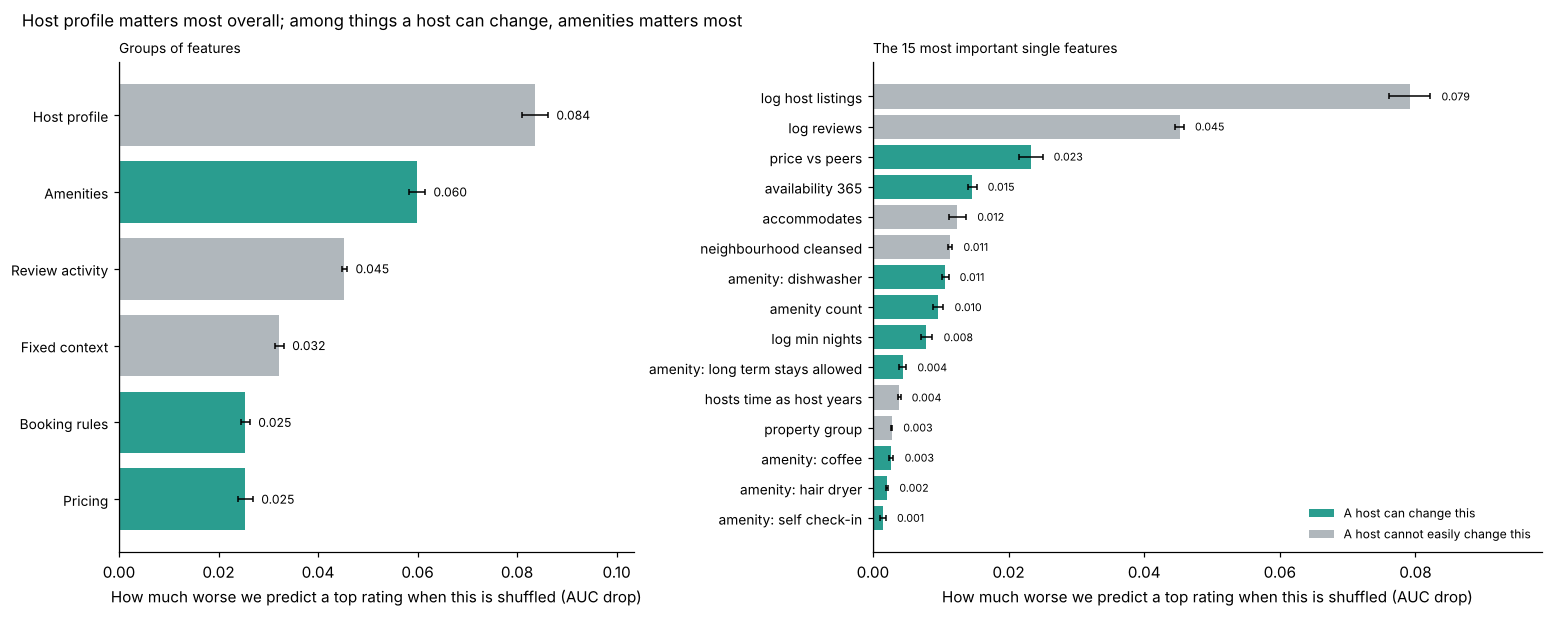

**Insight:** using all allowed features, the features separate top-rated from other listings with a score of 0.770 (0.5 = no better than guessing, 1.0 = perfect); fixed context alone scores 0.637. Shuffling **Host profile** hurts the prediction most (drop 0.084). Among the things a host can change, the order is **Amenities** (0.060) > **Booking rules** (0.025) > **Pricing** (0.025). **Booking rules** and **Pricing** are tied: the gap between them is smaller than the spread across repeats. The single most important feature is `log_host_listings` (0.079). This shows what goes with a top rating, not what causes one. Figure 26 shows which direction each feature pushes.

In [8]:
test_sub = X_te.sample(min(12000, len(X_te)), random_state=RNG)
y_sub = pd.Series(y_te, index=X_te.index).loc[test_sub.index].to_numpy()
base_auc = roc_auc_score(y_sub, model.predict_proba(test_sub[MODEL_COLS])[:, 1])


def perm_drop(cols, repeats=5, seed=RNG):
    rng = np.random.default_rng(seed)
    drops = []
    for _ in range(repeats):
        Xp = test_sub[MODEL_COLS].copy()
        Xp[cols] = test_sub[cols].to_numpy()[rng.permutation(len(test_sub))]
        drops.append(base_auc - roc_auc_score(y_sub, model.predict_proba(Xp)[:, 1]))
    return float(np.mean(drops)), float(np.std(drops))


with timer("Shuffling test: 6 groups × 5 repeats", kind="cpu-only"):
    gi = pd.DataFrame([(g, *perm_drop(c)) for g, c in GROUPS.items()], columns=["group", "drop", "sd"]).sort_values("drop")
with timer("Shuffling test: every single feature × 3 repeats", kind="cpu-only"):
    fi = pd.DataFrame([(c, *perm_drop([c], repeats=3)) for c in MODEL_COLS], columns=["feature", "drop", "sd"])
feat_group = {c: g for g, cs in GROUPS.items() for c in cs}
fi["group"] = fi["feature"].map(feat_group)
fi = fi.sort_values("drop").tail(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [1, 1.3]}, layout="constrained")


def value_labels(ax, d, fs):
    # write each value just past the right end of its whisker, so it never collides with the axis labels
    pad = (d["drop"] + d["sd"]).max() * 0.02
    for yi, (v, s) in enumerate(zip(d["drop"], d["sd"])):
        ax.text(max(v + s, 0) + pad, yi, f"{v:.3f}", va="center", fontsize=fs)
    ax.set_xlim(min(0, (d["drop"] - d["sd"]).min()) * 1.15, (d["drop"] + d["sd"]).max() * 1.2)


ax = axes[0]
ax.barh(gi["group"], gi["drop"], xerr=gi["sd"], color=[GROUP_COLORS[g] for g in gi["group"]], error_kw=dict(lw=1, capsize=2))
value_labels(ax, gi.reset_index(drop=True), 8)
ax.tick_params(axis="y", labelsize=9)
ax.axvline(0, color="#444444", lw=0.8)
ax.set_xlabel("How much worse we predict a top rating when this is shuffled (AUC drop)")
ax.set_title("Groups of features", loc="left", fontsize=9)
clean_axes(ax)
ax = axes[1]
ax.barh(fi["feature"].str.replace("_", " "), fi["drop"], xerr=fi["sd"], color=[GROUP_COLORS[g] for g in fi["group"]], error_kw=dict(lw=1, capsize=2))
value_labels(ax, fi.reset_index(drop=True), 7)
ax.axvline(0, color="#444444", lw=0.8)
ax.tick_params(axis="y", labelsize=9)
ax.set_xlabel("How much worse we predict a top rating when this is shuffled (AUC drop)")
ax.set_title("The 15 most important single features", loc="left", fontsize=9)
clean_axes(ax)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=LEVER_COLOR, label="A host can change this"), Patch(facecolor=CONTEXT_COLOR, label="A host cannot easily change this")],
          loc="lower right", fontsize=8, frameon=False)

lever_rank = gi[gi["group"].isin(LEVERS)].sort_values("drop", ascending=False)
lr = lever_rank.reset_index(drop=True)
ties = [(lr.loc[i, "group"], lr.loc[i + 1, "group"]) for i in range(len(lr) - 1)
        if lr.loc[i, "drop"] - lr.loc[i + 1, "drop"] < lr.loc[i, "sd"] + lr.loc[i + 1, "sd"]]
tie_text = (" " + " and ".join(f"**{a}** and **{b}** are tied: the gap between them is smaller than the spread across repeats." for a, b in ties)) if ties else ""

top_feat = fi.sort_values("drop", ascending=False).iloc[0]
fig.suptitle(f"{gi.iloc[-1]['group']} matters most overall; among things a host can change, {lever_rank.iloc[0]['group'].lower()} matters most",
             x=0.01, ha="left", fontsize=11)
save(fig, "fig25_permutation_importance")

display(Markdown(
    f"**Insight:** using all allowed features, the features separate top-rated from other listings with a score of {aucs[-1]:.3f} "
    f"(0.5 = no better than guessing, 1.0 = perfect); fixed context alone scores {aucs[0]:.3f}. "
    f"Shuffling **{gi.iloc[-1]['group']}** hurts the prediction most (drop {gi.iloc[-1]['drop']:.3f}). Among the things a host can change, the order is "
    f"{' > '.join(f'**{g}** ({d:.3f})' for g, d in zip(lever_rank['group'], lever_rank['drop']))}.{tie_text} "
    f"The single most important feature is `{top_feat['feature']}` ({top_feat['drop']:.3f}). "
    f"This shows what goes with a top rating, not what causes one. Figure 26 shows which direction each feature pushes."))

## Figure 26: If a host changes this feature, does the chance of a top rating go up or down, and is it the same for every kind of host? (interactive)

**In plain words:** pick a feature from the **dropdown**. The chart shows the predicted chance that a listing is top rated if it had each value of that feature, with everything else about the listing left as it is. One line is drawn for all listings and one for each host type (1 listing, 2-5 listings, 6 or more), so you can see whether the same feature works for small and large hosts.

**How to read the chart**
- A line that **rises** means more of this feature goes with a higher chance of a top rating. A line that **falls** means the opposite. A **flat** line means it makes little difference.
- The shaded band is where most listings sit (the middle 80%). Trust the lines most inside the band.
- The dashed line is the average predicted chance for all listings.
- All features share the same vertical scale, so you can compare how much each one matters. **Hover** to read exact values; click a name in the legend to hide a line.
- This shows a pattern in the data, not proof that changing a feature will raise a rating.

In [9]:
pdp_base = X_te.sample(min(3000, len(X_te)), random_state=RNG)[MODEL_COLS]
host_of = rated["host_type"]
GROUP_LINES = [("All listings", None, "#1F2D3D"), ("1 listing", "1 listing", GREEN), ("2-5 listings", "2-5 listings", ORANGE), ("6+ listings", "6+ listings", CORAL)]
REF = model.predict_proba(pdp_base)[:, 1].mean() * 100
amen_grid = np.unique(np.percentile(rated["amenity_count"], [2, 10, 25, 40, 50, 60, 75, 90, 98]).round())
# (label, model column, grid in real units, transform to model scale, real column for the shaded band, x label, x scale, lever?)
PDP_SPECS = [
    ("Amenities listed", "amenity_count", amen_grid, None, "amenity_count", "Number of amenities listed", "linear", True),
    ("Price vs similar listings", "price_vs_peers", np.array([0.5, 0.7, 0.85, 1.0, 1.15, 1.3, 1.6, 2.0]), None,
     "price_vs_peers", "Price as a multiple of similar listings (1.0 = typical)", "linear", True),
    ("Minimum nights", "log_min_nights", np.array([1, 2, 3, 4, 5, 7, 14, 30]), np.log1p, "minimum_nights_capped",
     "Minimum nights required (log scale)", "log", True),
    ("Days available (next 365)", "availability_365", np.array([0, 30, 90, 150, 210, 270, 330, 365]), None, "availability_365",
     "Days available in the next 365", "linear", True),
]


def pdp_curve(col, grid, tf, rows):
    base = rows[rows["price_vs_peers"].notna()] if col == "price_vs_peers" else rows
    out = []
    for v in grid:
        Xs = base.copy()
        Xs[col] = tf(v) if tf else v
        out.append(model.predict_proba(Xs)[:, 1].mean() * 100)
    return np.array(out)


with timer("Response curves (4 features × 4 host groups)", kind="cpu-only"):
    curves = {}
    for spec in PDP_SPECS:
        lab, col, grid, tf = spec[0], spec[1], spec[2], spec[3]
        for gname, hval, _ in GROUP_LINES:
            rows = pdp_base if hval is None else pdp_base[host_of.loc[pdp_base.index].to_numpy() == hval]
            curves[(lab, gname)] = (pdp_curve(col, grid, tf, rows), len(rows))

all_vals = np.concatenate([v[0] for v in curves.values()])
lo_y, hi_y = float(all_vals.min() - 2), float(all_vals.max() + 2)
bands = {s[0]: [float(q) for q in rated[s[4]].quantile([0.1, 0.9])] for s in PDP_SPECS}

traces, vis_blocks = [], []
for li, spec in enumerate(PDP_SPECS):
    lab, grid = spec[0], spec[2]
    for gname, hval, color in GROUP_LINES:
        vals, n_rows = curves[(lab, gname)]
        traces.append(go.Scatter(
            x=[float(v) for v in grid], y=[float(v) for v in vals], mode="lines+markers", name=gname, legendgroup=gname,
            line=dict(color=color, width=3.5 if hval is None else 2, dash="solid" if hval is None else "dot"),
            marker=dict(size=7), visible=(li == 0), showlegend=True,
            hovertemplate=f"<b>{gname}</b><br>{lab}: %{{x}}<br>Predicted top-rated chance: %{{y:.1f}}%<extra></extra>"))


def lever_layout(i):
    spec = PDP_SPECS[i]
    b0, b1 = bands[spec[0]]
    return {"xaxis.title.text": spec[5], "xaxis.type": spec[6],
            "shapes": [dict(type="rect", xref="x", yref="paper", x0=b0, x1=b1, y0=0, y1=1, fillcolor="#EAF2F8", opacity=0.7,
                            line=dict(width=0), layer="below"),
                       dict(type="line", xref="paper", yref="y", x0=0, x1=1, y0=REF, y1=REF, line=dict(color="#444444", width=1, dash="dash"))]}


buttons = []
for i, spec in enumerate(PDP_SPECS):
    vis = [j // len(GROUP_LINES) == i for j in range(len(traces))]
    buttons.append(dict(label=spec[0], method="update", args=[{"visible": vis}, lever_layout(i)]))

fig = go.Figure(data=traces)
first = lever_layout(0)
fig.update_layout(updatemenus=[dict(type="dropdown", direction="down", x=0.0, y=1.13, xanchor="left", yanchor="bottom", showactive=True, buttons=buttons)],
                  xaxis=dict(title=dict(text=PDP_SPECS[0][5]), type=PDP_SPECS[0][6]), shapes=first["shapes"],
                  yaxis=dict(title=dict(text="Predicted chance of being top rated (%)"), range=[lo_y, hi_y]),
                  legend=dict(orientation="h", x=0, y=-0.22), hovermode="closest")
finish(fig, "fig26_feature_response_by_host_type", "If a host changes this feature, how does the chance of a top rating move?",
       "Pick a feature in the dropdown. Dotted lines split the answer by host type. Shaded band = middle 80% of listings.", height=640, bottom=130, top=150)

rows_sum = []
for spec in PDP_SPECS:
    lab = spec[0]
    v_all = curves[(lab, "All listings")][0]
    same = all(np.sign(curves[(lab, g)][0][-1] - curves[(lab, g)][0][0]) == np.sign(v_all[-1] - v_all[0]) for g in ["1 listing", "2-5 listings", "6+ listings"])
    rows_sum.append(dict(lever=lab, low=v_all.min(), high=v_all.max(), span=v_all.max() - v_all.min(), best=spec[2][int(np.argmax(v_all))],
                         worst=spec[2][int(np.argmin(v_all))], same_direction=same,
                         single=curves[(lab, "1 listing")][0].max() - curves[(lab, "1 listing")][0].min(),
                         big=curves[(lab, "6+ listings")][0].max() - curves[(lab, "6+ listings")][0].min()))
pdp_sum = pd.DataFrame(rows_sum).sort_values("span", ascending=False)
top_move = pdp_sum.iloc[0]
lines = "; ".join(f"**{r.lever}**: {r.low:.1f}% to {r.high:.1f}% (highest at {r.best:g}, lowest at {r.worst:g})" for r in pdp_sum.itertuples())
display(Markdown(
    f"**Insight:** predicted chance of a top rating for each feature, biggest change first: {lines}. The average is {REF:.1f}%. "
    f"{top_move['lever']} makes the biggest difference. For {int(pdp_sum['same_direction'].sum())} of the 4 features the line runs in the same direction for "
    f"single-listing, 2-5 listing and 6+ listing hosts, so the advice does not depend on host size for those features. "
    f"These are patterns among listings that already have reviews, not proof that changing a feature will raise a rating."))
pdp_sum.round(2)

Figure()

**Insight:** predicted chance of a top rating for each feature, biggest change first: **Price vs similar listings**: 41.5% to 63.3% (highest at 2, lowest at 0.5); **Days available (next 365)**: 40.0% to 60.8% (highest at 30, lowest at 365); **Amenities listed**: 49.9% to 64.8% (highest at 61, lowest at 6); **Minimum nights**: 53.5% to 62.7% (highest at 30, lowest at 1). The average is 55.9%. Price vs similar listings makes the biggest difference. For 4 of the 4 features the line runs in the same direction for single-listing, 2-5 listing and 6+ listing hosts, so the advice does not depend on host size for those features. These are patterns among listings that already have reviews, not proof that changing a feature will raise a rating.

,lever,low,high,span,best,worst,same_direction,single,big
1,Price vs similar listings,41.54,63.28,21.73,2.0,0.5,True,21.63,19.51
3,Days available (next 365),39.98,60.79,20.81,30.0,365.0,True,24.03,13.48
0,Amenities listed,49.94,64.83,14.88,61.0,6.0,True,11.63,19.44
2,Minimum nights,53.48,62.65,9.17,30.0,1.0,True,7.36,12.12


## Step 3: What should a host improve first to reach a top rating?

The things a host can change are ranked by how much they matter for a top rating (Figure 25), and each is paired with what its curve showed (Figure 26). The table is filled from the results above.

In [10]:
RESPONSE_OF = {"Pricing": ["Price vs similar listings"], "Amenities": ["Amenities listed"],
               "Booking rules": ["Minimum nights", "Days available (next 365)"]}
pdp_idx = pdp_sum.set_index("lever")
rows = []
for rank, (g, d, s) in enumerate(zip(lever_rank["group"], lever_rank["drop"], lever_rank["sd"]), start=1):
    resp = "; ".join(f"{k}: {pdp_idx.loc[k, 'low']:.0f}% to {pdp_idx.loc[k, 'high']:.0f}%, highest at {pdp_idx.loc[k, 'best']:g}"
                     for k in RESPONSE_OF[g] if k in pdp_idx.index)
    same = all(bool(pdp_idx.loc[k, "same_direction"]) for k in RESPONSE_OF[g] if k in pdp_idx.index)
    rows.append(f"| {rank} | **{g}** | {d:.3f} (±{s:.3f}) | {resp} | {'Yes' if same else 'No'} |")
display(Markdown("| Priority | What the host can change | Importance (drop when shuffled) | Chance of a top rating across its values | Same direction for small and large hosts? |\n|---|---|---|---|---|\n" + "\n".join(rows)))
notes = []
if len(ties):
    notes.append("Where two features are tied (see Figure 25), treat them as equal priority and let the curve decide which is easier for the host to change.")
if pdp_idx.loc["Price vs similar listings", "best"] > 1:
    notes.append("The price curve rises: listings priced above their peers are top-rated more often. That most likely reflects quality (better listings can charge more), so it does **not** mean that raising prices will raise ratings; it means a price far below similar listings is a warning sign.")
if pdp_idx.loc["Days available (next 365)", "best"] < 100:
    notes.append("The availability curve falls: listings open all year are top-rated less often. Busy, well-booked listings may simply be better ones, so this too describes who gets high ratings, not a setting that guarantees one.")
if notes:
    display(Markdown("**Read this with care.** " + " ".join(notes)))
display(Markdown(
    f"Fixed context (room type, size, borough) and host profile are not things a host can change, but they matter for expectations: their importance is "
    f"{gi.set_index('group').loc['Fixed context', 'drop']:.3f} and {gi.set_index('group').loc['Host profile', 'drop']:.3f}, so a host should compare results with similar listings, not with the whole city."))

| Priority | What the host can change | Importance (drop when shuffled) | Chance of a top rating across its values | Same direction for small and large hosts? |
|---|---|---|---|---|
| 1 | **Amenities** | 0.060 (±0.002) | Amenities listed: 50% to 65%, highest at 61 | Yes |
| 2 | **Booking rules** | 0.025 (±0.001) | Minimum nights: 53% to 63%, highest at 30; Days available (next 365): 40% to 61%, highest at 30 | Yes |
| 3 | **Pricing** | 0.025 (±0.002) | Price vs similar listings: 42% to 63%, highest at 2 | Yes |

**Read this with care.** Where two features are tied (see Figure 25), treat them as equal priority and let the curve decide which is easier for the host to change. The price curve rises: listings priced above their peers are top-rated more often. That most likely reflects quality (better listings can charge more), so it does **not** mean that raising prices will raise ratings; it means a price far below similar listings is a warning sign. The availability curve falls: listings open all year are top-rated less often. Busy, well-booked listings may simply be better ones, so this too describes who gets high ratings, not a setting that guarantees one.

Fixed context (room type, size, borough) and host profile are not things a host can change, but they matter for expectations: their importance is 0.032 and 0.084, so a host should compare results with similar listings, not with the whole city.

## Step 4: What could make these answers wrong?

- **Association is not cause.** Guests rate against their own expectations, and cleanliness, host communication and the exact stay are not in the data. A feature that predicts top ratings may not raise a rating when changed.
- **Only reviewed listings.** New listings with no rating are excluded, so the findings may not hold for them.
- **Overlapping features.** Size variables, price measures and amenity counts move together (Figure 22), so single-feature importance is shared between them. Groups are the safer reading.
- **Amenities mark home types.** Many mid-frequency amenities describe a kind of property, so an amenity that goes with top ratings is not necessarily one a host can add to improve a rating. The advice is therefore given on the amenity count, not on individual amenities.
- **Relative price is only defined for listed prices.** Listings with no price (about a third) have no relative price, so the pricing curve describes listings that publish a price.
- **Ratings sit near the top.** Median ratings are close to the 4.8 cut point (see the univariate part), so small differences decide the class, which limits how well any prediction can do (Figure 24).
- **Thin geography.** Outer boroughs have few listings, so single bubbles on the map are indicative only; the 95% intervals in the hover show how wide the uncertainty is.
- **One snapshot.** The data is one scrape (19 June 2026), so nothing here shows how a rating changes when a host changes something over time.

## Step 5: Final decision table: which features go into the answer for a top rating?

Two tables. **Table A** lists every analysis choice in this part and why, in the same format as the earlier parts (cleaning choices are in the cleaning part). **Table B** is the final call on each feature group: whether it stays in the final answer and how it should be used, based on the importance results above. Every statement in Table A is something the code above actually does.

In [11]:
n_rated, n_all = len(rated), len(df)
n_small = int((rated["room_group"] == "Shared or hotel room").sum())
n_nolevel = int(rated["price_vs_peers"].isna().sum())
display(Markdown(f"""
**Table A: analysis decisions**

| Column / issue | Decision | Because |
|---|---|---|
| Sample | {n_rated:,} rated listings for everything involving `top_rated`; all {n_all:,} only for the map's coordinates | A missing target cannot be filled without inventing answers; results apply to reviewed listings only |
| Review sub-scores, `host_is_superhost` | Never used as features | Leakage: they come from the same stays as the rating or depend on it |
| `host_identity_verified` | Not used | Near-universal ({VERIFIED:.1f}% of rated listings), so it carries almost no information; consistent with the univariate and bivariate decisions |
| Host response rate, acceptance rate, response time | Not used | Completely empty in this snapshot |
| `latitude`, `longitude` | Used for the map only; `neighbourhood_cleansed` is the location feature | Borough already covers location; the map shows how location and host type interact |
| `price` | `log(price_capped_imp)` plus the `price_missing` flag from cleaning | Skew (univariate); missing price is linked to listings that cannot be booked, so the flag carries signal |
| Relative price (new) | Observed `price_capped` divided by the median of listings in the same borough, room type and capacity group (at least 10 priced peers); missing for {n_nolevel:,} rated listings | Raw price mixes location and size; relative price is also something a host can change |
| `room_type` | Shared and hotel rooms merged into one group | Only {n_small:,} rated listings, too small to compare separately |
| `property_type` | Top 5 kept, the rest grouped as "Other property type" | Long tail of rare labels |
| `accommodates` | Numeric; grouped (1-2, 3-4, 5-6, 7+) for relative price | Not linear in the bivariate part; complete and the main size measure |
| `bedrooms`, `beds`, `bathrooms` | `_imp` columns (median by room type) with their `_missing` flags and `size_extreme` | Decisions made in cleaning and univariate; the flags let us test whether imputed rows behave differently |
| `neighbourhood_cleansed` | All boroughs kept; boroughs under {MIN_N} rated listings hidden in a map step | Rates from small groups are unstable (uneven borough sizes) |
| `calculated_host_listings_count` | Grouped 1, 2-5, 6+ on the map and in the curves; `log1p` | Long right tail; three groups show whether the gap grows with portfolio size |
| `hosts_time_as_host_years` | Numeric | The bivariate part found a weak, non-linear pattern, so no linear effect is assumed |
| `number_of_reviews` | `log1p`; own group "Review activity", not counted as something a host can change | Result of past stays, not something a host sets |
| `minimum_nights_capped`, `availability_365` | `log1p` for minimum nights; availability as is | Skew; 0 days available is ambiguous (booked or blocked) |
| `amenities` | Amenity count (length of the JSON list, as in the bivariate part) plus up to {len(AMEN)} amenities offered by 10-80% of listings | Basics cannot separate listings; the count is the candidate chosen in the bivariate part |
| Overlapping features | Spearman correlation heatmap (Figure 22); importance read by group | Related features share credit, so single features understate their group |
| Small groups | Map steps with fewer than {MIN_N} rated listings are hidden; every map bubble shows a 95% Wilson interval in its hover | Small samples give unstable rates |
| Classes | No resampling | Classes are close to balanced ({BASE:.0f}% top rated) |
| Predicting a top rating | All allowed features used together, 75/25 stratified split, scored by AUC; a simple straight-line rule as the comparison | Allows effects that bend or interact; the comparison shows whether that matters |
| Uncertainty of the score | 95% bootstrap interval on the test AUC (1,000 resamples, shared across rows) and 5-fold cross-validation | One split can be lucky; the interval and the folds show how stable the score is |
| Importance | Whole groups shuffled together (5 repeats); single features shuffled (3 repeats); spread across repeats shown | Related features share credit, so single features understate their group |
| Charts | Figures 22 to 26 plus 23b: four interactive Plotly charts (correlation heatmap, borough map with Play, the same story as animated bars with Play, feature curves with a dropdown) and two static charts | Each answers a part of the main question: what overlaps, where, how good, what matters, and which way to move |
| Timing | Every computational step timed; reported in Step 8 | Gives a CPU baseline for the later CPU vs RAPIDS comparison |
"""))

# Table B: final decision for each feature group, filled from the results
gdrop = gi.set_index("group")
step_gain = dict(zip(names, gains))
CONTENT = {g: ", ".join(c.replace("_", " ") for c in cols[:4]) + (f" and {len(cols) - 4} more" if len(cols) > 4 else "")
           for g, cols in GROUPS.items()}
USE = {"Fixed context": "Use it to pick comparison listings, so hosts judge themselves against similar ones",
       "Host profile": "Fixed facts only; a host cannot change tenure or portfolio size in the short run",
       "Pricing": "Advise on price compared with similar listings, not the whole city (Figure 26)",
       "Booking rules": "Secondary advice unless its curve in Figure 26 moves clearly",
       "Amenities": "Advise on the amenity count (Figure 26); individual amenities are not ranked here",
       "Review activity": "Control only; it keeps other effects honest but a host cannot set it"}
rows = []
for g in GROUPS:
    d, sd = gdrop.loc[g, "drop"], gdrop.loc[g, "sd"]
    keep = d > max(2 * sd, 0.002)
    verdict = "**Keep in the final answer**" if keep else "**Weak signal: re-test without it**"
    rows.append(f"| {g} | {'Host can change' if g in LEVERS else 'Fixed'} | {CONTENT[g]} | {d:.3f} (±{sd:.3f}) | {step_gain[g]:+.3f} | {verdict}. {USE[g]} |")
display(Markdown("**Table B: final decision for each feature group**\n\n"
                 "| Feature group | Can a host change it? | Main features | Importance (drop when shuffled) | Score gained when the group is added | Final decision |\n|---|---|---|---|---|---|\n"
                 + "\n".join(rows)
                 + "\n\n*Rule used: a group is kept if scrambling it lowers AUC by more than twice its spread and by at least 0.002; otherwise it is flagged as a weak signal and should be re-tested without it before the final answer is fixed.*"))


**Table A: analysis decisions**

| Column / issue | Decision | Because |
|---|---|---|
| Sample | 70,708 rated listings for everything involving `top_rated`; all 92,635 only for the map's coordinates | A missing target cannot be filled without inventing answers; results apply to reviewed listings only |
| Review sub-scores, `host_is_superhost` | Never used as features | Leakage: they come from the same stays as the rating or depend on it |
| `host_identity_verified` | Not used | Near-universal (98.4% of rated listings), so it carries almost no information; consistent with the univariate and bivariate decisions |
| Host response rate, acceptance rate, response time | Not used | Completely empty in this snapshot |
| `latitude`, `longitude` | Used for the map only; `neighbourhood_cleansed` is the location feature | Borough already covers location; the map shows how location and host type interact |
| `price` | `log(price_capped_imp)` plus the `price_missing` flag from cleaning | Skew (univariate); missing price is linked to listings that cannot be booked, so the flag carries signal |
| Relative price (new) | Observed `price_capped` divided by the median of listings in the same borough, room type and capacity group (at least 10 priced peers); missing for 22,330 rated listings | Raw price mixes location and size; relative price is also something a host can change |
| `room_type` | Shared and hotel rooms merged into one group | Only 261 rated listings, too small to compare separately |
| `property_type` | Top 5 kept, the rest grouped as "Other property type" | Long tail of rare labels |
| `accommodates` | Numeric; grouped (1-2, 3-4, 5-6, 7+) for relative price | Not linear in the bivariate part; complete and the main size measure |
| `bedrooms`, `beds`, `bathrooms` | `_imp` columns (median by room type) with their `_missing` flags and `size_extreme` | Decisions made in cleaning and univariate; the flags let us test whether imputed rows behave differently |
| `neighbourhood_cleansed` | All boroughs kept; boroughs under 30 rated listings hidden in a map step | Rates from small groups are unstable (uneven borough sizes) |
| `calculated_host_listings_count` | Grouped 1, 2-5, 6+ on the map and in the curves; `log1p` | Long right tail; three groups show whether the gap grows with portfolio size |
| `hosts_time_as_host_years` | Numeric | The bivariate part found a weak, non-linear pattern, so no linear effect is assumed |
| `number_of_reviews` | `log1p`; own group "Review activity", not counted as something a host can change | Result of past stays, not something a host sets |
| `minimum_nights_capped`, `availability_365` | `log1p` for minimum nights; availability as is | Skew; 0 days available is ambiguous (booked or blocked) |
| `amenities` | Amenity count (length of the JSON list, as in the bivariate part) plus up to 40 amenities offered by 10-80% of listings | Basics cannot separate listings; the count is the candidate chosen in the bivariate part |
| Overlapping features | Spearman correlation heatmap (Figure 22); importance read by group | Related features share credit, so single features understate their group |
| Small groups | Map steps with fewer than 30 rated listings are hidden; every map bubble shows a 95% Wilson interval in its hover | Small samples give unstable rates |
| Classes | No resampling | Classes are close to balanced (56% top rated) |
| Predicting a top rating | All allowed features used together, 75/25 stratified split, scored by AUC; a simple straight-line rule as the comparison | Allows effects that bend or interact; the comparison shows whether that matters |
| Uncertainty of the score | 95% bootstrap interval on the test AUC (1,000 resamples, shared across rows) and 5-fold cross-validation | One split can be lucky; the interval and the folds show how stable the score is |
| Importance | Whole groups shuffled together (5 repeats); single features shuffled (3 repeats); spread across repeats shown | Related features share credit, so single features understate their group |
| Charts | Figures 22 to 26 plus 23b: four interactive Plotly charts (correlation heatmap, borough map with Play, the same story as animated bars with Play, feature curves with a dropdown) and two static charts | Each answers a part of the main question: what overlaps, where, how good, what matters, and which way to move |
| Timing | Every computational step timed; reported in Step 8 | Gives a CPU baseline for the later CPU vs RAPIDS comparison |


**Table B: final decision for each feature group**

| Feature group | Can a host change it? | Main features | Importance (drop when shuffled) | Score gained when the group is added | Final decision |
|---|---|---|---|---|---|
| Fixed context | Fixed | room group, property group, accommodates, bedrooms imp and 7 more | 0.032 (±0.001) | +0.137 | **Keep in the final answer**. Use it to pick comparison listings, so hosts judge themselves against similar ones |
| Host profile | Fixed | hosts time as host years, log host listings | 0.084 (±0.003) | +0.068 | **Keep in the final answer**. Fixed facts only; a host cannot change tenure or portfolio size in the short run |
| Pricing | Host can change | log price, price missing, price vs peers | 0.025 (±0.002) | +0.010 | **Keep in the final answer**. Advise on price compared with similar listings, not the whole city (Figure 26) |
| Booking rules | Host can change | log min nights, availability 365 | 0.025 (±0.001) | +0.014 | **Keep in the final answer**. Secondary advice unless its curve in Figure 26 moves clearly |
| Amenities | Host can change | amenity count, amenity: hot water, amenity: iron, amenity: hangers and 37 more | 0.060 (±0.002) | +0.020 | **Keep in the final answer**. Advise on the amenity count (Figure 26); individual amenities are not ranked here |
| Review activity | Fixed | log reviews | 0.045 (±0.001) | +0.021 | **Keep in the final answer**. Control only; it keeps other effects honest but a host cannot set it |

*Rule used: a group is kept if scrambling it lowers AUC by more than twice its spread and by at least 0.002; otherwise it is flagged as a weak signal and should be re-tested without it before the final answer is fixed.*

## Step 6: Key takeaways: what predicts a top rating and what should hosts improve first?

In [12]:
lever_text = ", ".join(f"{g} ({d:.3f})" for g, d in zip(lever_rank["group"], lever_rank["drop"]))
big_gap = bm[bm["Host type"] != "All hosts"].groupby("Host type").apply(lambda g: (g["rate"] * g["n"]).sum() / g["n"].sum())
display(Markdown(f"""
- **What overlaps:** the size measures and price move together (Figure 22), so importance is read by group, not by single feature.
- **Geography:** the top-rated rate is highest in {", ".join(top3)} and lowest in {", ".join(bot3)}, and the pattern shifts with host type (Figure 23).
- **How well a top rating can be predicted:** all features together reach AUC {full['auc']:.3f} on unseen rated listings (95% interval {full['low']:.3f} to {full['high']:.3f}; 5-fold cross-validation {full['cv_mean']:.3f}); fixed context alone (room type, size, borough) reaches {aucs[0]:.3f}, everything a host cannot change reaches {res.set_index('model').loc['Fixed facts only (host cannot change)', 'auc']:.3f}, and the simple straight-line rule reaches {lin_r['auc']:.3f} (Figure 24).
- **Biggest groups overall:** {gi.iloc[-1]["group"]} ({gi.iloc[-1]["drop"]:.3f}) matters most, but a host cannot change it quickly; it is context for expectations.
- **What a host can change, by importance:** {lever_text} (Figure 25).{tie_text.replace("**", "")} The direction and size of each feature, split by host type, are in Figure 26.
- **Pricing is relative:** compare a listing with similar ones, not with the whole city.
- **Host type:** single-listing hosts are top-rated {big_gap.get("1 listing", np.nan):.0f}% of the time, 2-5 listing hosts {big_gap.get("2-5 listings", np.nan):.0f}% and 6+ listing hosts {big_gap.get("6+ listings", np.nan):.0f}% (Figure 23); this describes who hosts are, not something a host can change.
- **Next:** test whether the host-choice features alone still predict a top rating in boroughs not used to find them, and put the map and the ranking of what a host can change on the dashboard.
"""))


- **What overlaps:** the size measures and price move together (Figure 22), so importance is read by group, not by single feature.
- **Geography:** the top-rated rate is highest in Richmond upon Thames, Merton, Wandsworth and lowest in City of London, Westminster, Camden, and the pattern shifts with host type (Figure 23).
- **How well a top rating can be predicted:** all features together reach AUC 0.770 on unseen rated listings (95% interval 0.763 to 0.777; 5-fold cross-validation 0.772); fixed context alone (room type, size, borough) reaches 0.637, everything a host cannot change reaches 0.728, and the simple straight-line rule reaches 0.725 (Figure 24).
- **Biggest groups overall:** Host profile (0.084) matters most, but a host cannot change it quickly; it is context for expectations.
- **What a host can change, by importance:** Amenities (0.060), Booking rules (0.025), Pricing (0.025) (Figure 25). Booking rules and Pricing are tied: the gap between them is smaller than the spread across repeats. The direction and size of each feature, split by host type, are in Figure 26.
- **Pricing is relative:** compare a listing with similar ones, not with the whole city.
- **Host type:** single-listing hosts are top-rated 69% of the time, 2-5 listing hosts 59% and 6+ listing hosts 37% (Figure 23); this describes who hosts are, not something a host can change.
- **Next:** test whether the host-choice features alone still predict a top rating in boroughs not used to find them, and put the map and the ranking of what a host can change on the dashboard.


## Step 7: What to carry forward

- The advice to hosts is the priority table in Step 3, in that order.
- `host_identity_verified` stays out of the final answer (near-universal), matching the bivariate decision.
- The univariate part's closing note that refers to the multivariate part should cite **Figure 25** (feature importance) and this part's figure numbers 22 to 26.

## Step 8: CPU timing

Timing is kept **at the end**, not mixed into the analytical figures. Each computational step above was wrapped in `timer()`, so the table below measures the repeatable data operations, not the time spent drawing Matplotlib or Plotly charts.

- **Steps marked `pandas`** are DataFrame operations (load, grouping, correlation). These are the steps a GPU run with `cudf.pandas` can accelerate.
- **Steps marked `cpu-only`** are Python-level or scikit-learn work (JSON parsing, fitting, resampling, shuffling tests). They are reported separately because they would run on the CPU even on a GPU runtime; they are not a fair test of cuDF.
- **How to run on GPU (Colab, GPU runtime):** restart the kernel, uncomment `%load_ext cudf.pandas` at the top of the first code cell **before pandas is imported**, set `MODE = "GPU"`, update `DATA_PATH`, `FIG_DIR` and `DOC_DIR` to the Colab locations, and run all cells. Run in the same session as the CPU run, and report the second run, because the first includes start-up overhead.
- **Fair comparison:** the CPU and GPU runs must use the same cleaned file and the same cells. Report the observed times and speed-up without assuming the GPU must be faster.
- The saved outputs show the run on the machine named in the table; re-run the notebook on your own computer to refresh the baseline.

In [13]:
timing = pd.DataFrame(timing_rows)
timing["Seconds"] = timing["Seconds"].round(3)
subtotal_pandas = timing.loc[timing["Kind"] == "pandas", "Seconds"].sum()
subtotal_cpu = timing.loc[timing["Kind"] == "cpu-only", "Seconds"].sum()
summary = pd.DataFrame([{"Step": "Subtotal: pandas steps (cuDF-comparable)", "Kind": "pandas", "Seconds": round(subtotal_pandas, 3)},
                        {"Step": "Subtotal: CPU-only steps (JSON, scikit-learn)", "Kind": "cpu-only", "Seconds": round(subtotal_cpu, 3)},
                        {"Step": "Total", "Kind": "all", "Seconds": round(subtotal_pandas + subtotal_cpu, 3)}])
out = pd.concat([timing, summary], ignore_index=True)
out["Mode"] = MODE
out["Machine"] = platform.platform()
out.to_csv(f"{DOC_DIR}/timing_multivariate_{MODE.lower()}.csv", index=False)
print("Machine:", platform.platform(), "| Mode:", MODE)
out[["Step", "Kind", "Seconds"]]

Machine: Linux-6.18.44-fc-v77-x86_64-with-glibc2.39 | Mode: CPU


,Step,Kind,Seconds
0,Load cleaned CSV,pandas,2.265
1,Create rated subset,pandas,0.091
2,"Feature engineering (grouping, relative price, logs)",pandas,0.070
3,Amenity JSON parsing,cpu-only,0.760
4,Amenity indicator matrix,cpu-only,1.050
5,Spearman correlation matrix,pandas,0.318
6,Borough × host-type aggregation,pandas,0.102
7,Train/test split,pandas,0.072
8,Add feature groups one at a time (6 fits),cpu-only,8.059
9,Fixed-facts-only and host-choices-only (2 fits),cpu-only,2.712


In [14]:
share = subtotal_pandas / (subtotal_pandas + subtotal_cpu) * 100
slowest = timing.sort_values("Seconds", ascending=False).head(3)
display(Markdown(
    f"**Benchmark baseline ({MODE}, single run):** the pandas steps that a GPU run could speed up took **{subtotal_pandas:.1f} s** "
    f"({share:.0f}% of the measured time); the CPU-only steps took **{subtotal_cpu:.1f} s**. The three slowest steps were "
    + ", ".join(f"*{r.Step}* ({r.Seconds:.1f} s)" for r in slowest.itertuples())
    + ". Fitting, resampling and shuffling dominate, so a GPU run of this notebook would mainly shorten loading, grouping and correlation, "
      "not those steps. These timings are a single-run baseline, not evidence of a CPU or GPU advantage."))

**Benchmark baseline (CPU, single run):** the pandas steps that a GPU run could speed up took **2.9 s** (3% of the measured time); the CPU-only steps took **86.8 s**. The three slowest steps were *5-fold cross-validation (3 sets of features: 15 fits)* (29.5 s), *95% intervals for the score (1,000 resamples)* (23.7 s), *Shuffling test: every single feature × 3 repeats* (15.6 s). Fitting, resampling and shuffling dominate, so a GPU run of this notebook would mainly shorten loading, grouping and correlation, not those steps. These timings are a single-run baseline, not evidence of a CPU or GPU advantage.